# Customer Churn Prediction

# Milestone 3: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) helps us understand the characteristics of the dataset through statistical summaries and visualizations. The goal is to identify trends, relationships, patterns, and potential issues before preparing the data for machine learning.

The insights gained during this phase will guide feature engineering, preprocessing, and model selection.

In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Visualization style
sns.set_theme(style="whitegrid")

# Figure size
plt.rcParams["figure.figsize"] = (8,5)

## Load Dataset

Load the IBM Telco Customer Churn dataset for exploratory analysis.

In [2]:
# Load dataset

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Data Preparation

Before visualization, we convert the `TotalCharges` column into a numeric data type by replacing blank values with missing values (`NaN`).

In [3]:
# Replace blank strings with NaN

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Distribution of Target Variable

Understanding the distribution of the target variable helps determine whether the dataset is balanced or imbalanced.

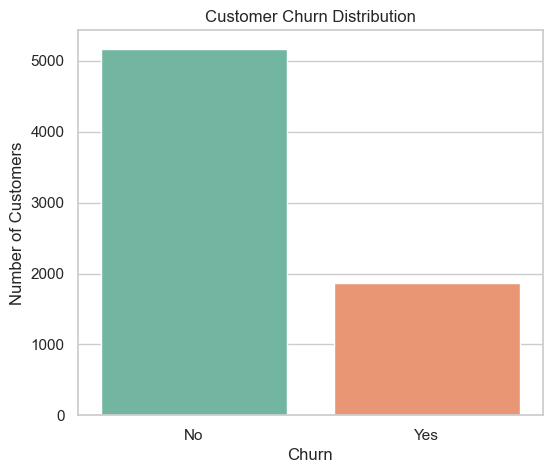

In [5]:
# Churn distribution

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

### Observation

The majority of customers belong to the **No Churn** category.

### Business Insight

The dataset is moderately imbalanced, indicating that more customers stay with the company than leave.

This imbalance should be considered during model training.

## Gender Distribution

Analyze the gender composition of customers.

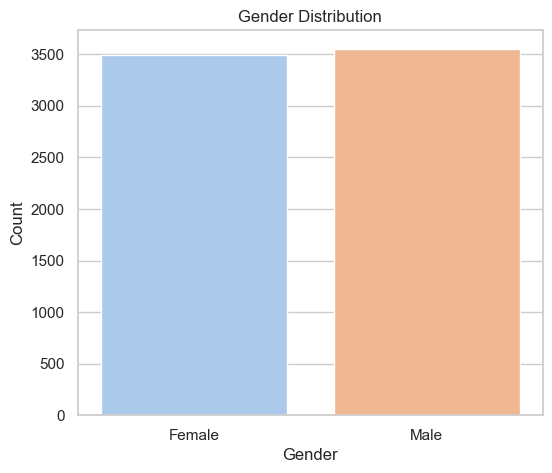

In [6]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender",
    hue="gender",
    palette="pastel",
    legend=False
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

### Observation

The dataset contains an almost equal number of male and female customers.

### Business Insight

Gender alone may not be a strong predictor of customer churn.

## Contract Type Distribution

Analyze the frequency of different customer contract types.

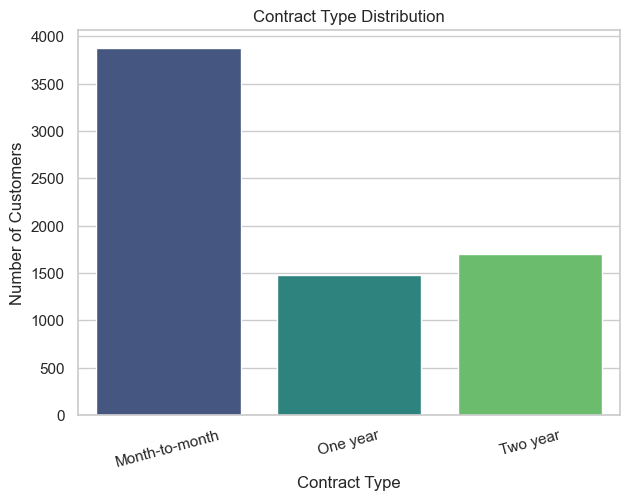

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Contract",
    palette="viridis",
    legend=False
)

plt.title("Contract Type Distribution")

plt.xlabel("Contract Type")

plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Observation

Most customers are subscribed to Month-to-month contracts.

### Business Insight

Customers with shorter contracts may have a greater tendency to churn because they have lower commitment.

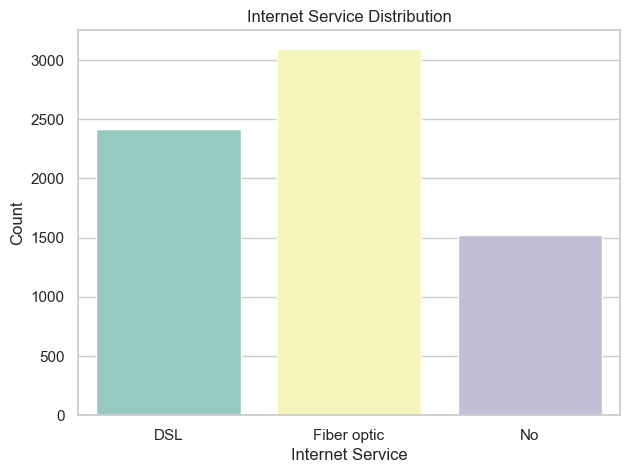

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="InternetService",
    palette="Set3",
    legend=False
)

plt.title("Internet Service Distribution")

plt.xlabel("Internet Service")

plt.ylabel("Count")

plt.show()

### Observation

Fiber optic is the most commonly used internet service.

### Business Insight

We will later examine whether Fiber optic customers churn more frequently than DSL users.

## Churn by Gender

This visualization compares churn rates between male and female customers to determine whether gender has any significant impact on customer churn.

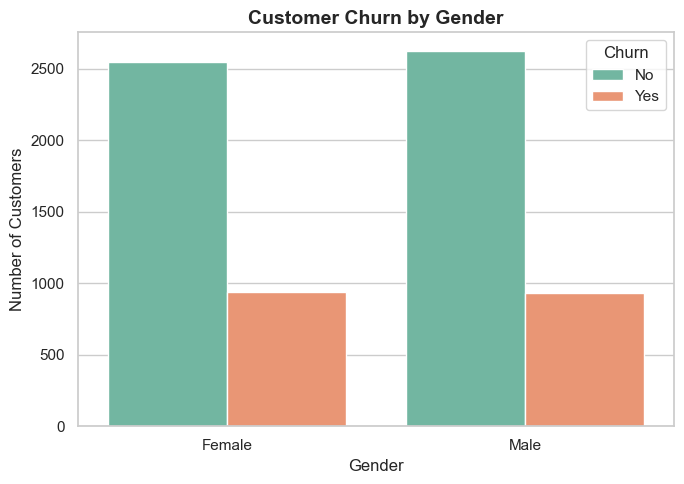

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

Male and female customers exhibit very similar churn patterns.

### Business Insight

Gender does not appear to be a major factor influencing customer churn.

## Churn by Contract Type

This visualization examines how customer churn varies across different contract types.

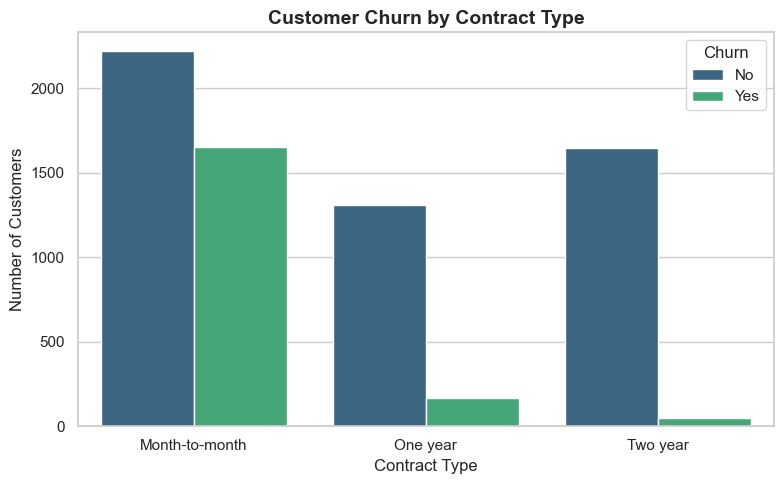

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="viridis"
)

plt.title("Customer Churn by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

Customers with Month-to-month contracts have a significantly higher churn count compared to customers with one-year or two-year contracts.

### Business Insight

Long-term contracts appear to improve customer retention. Encouraging customers to switch from monthly plans to annual plans could reduce churn.

## Churn by Internet Service

Analyze customer churn across different internet service types.

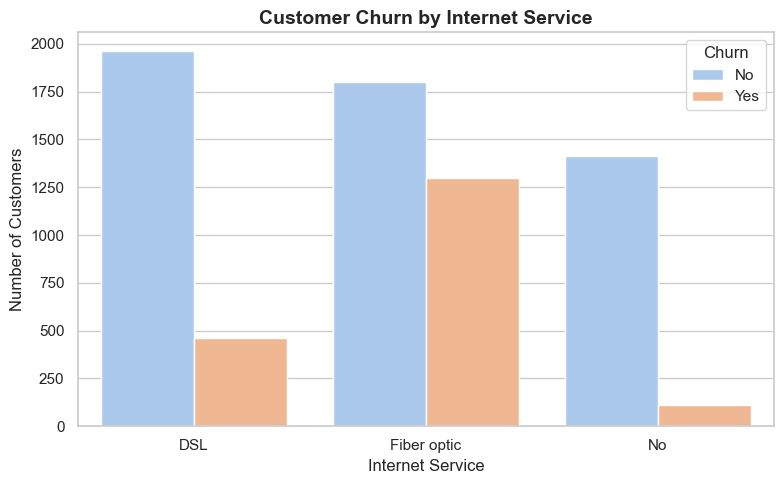

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="pastel"
)

plt.title("Customer Churn by Internet Service", fontsize=14, fontweight="bold")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

Fiber optic customers appear to churn more frequently than DSL customers.

### Business Insight

This may indicate higher customer expectations, pricing concerns, or service quality issues among Fiber optic users.

## Churn by Payment Method

Analyze whether payment methods are associated with customer churn.

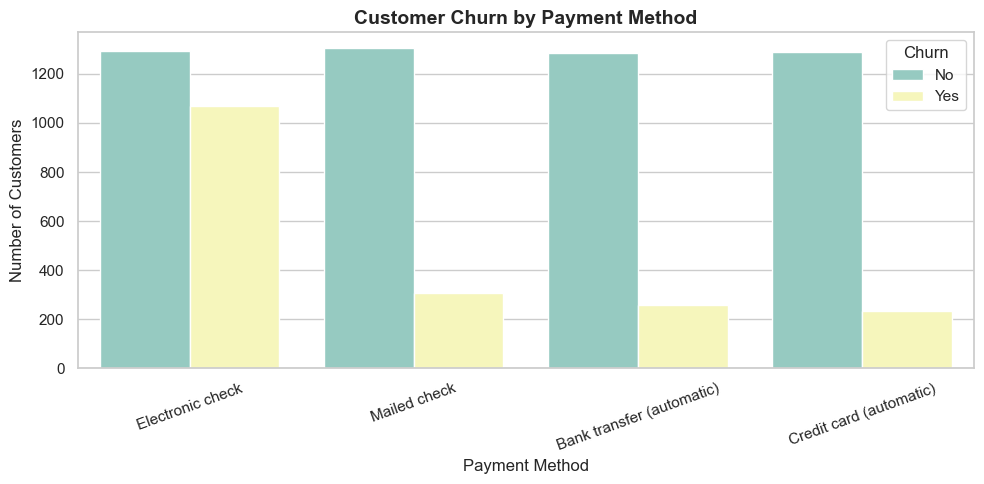

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Set3"
)

plt.title("Customer Churn by Payment Method", fontsize=14, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Observation

Electronic check customers appear to have a noticeably higher churn count than customers using other payment methods.

### Business Insight

The payment experience or customer segment associated with electronic checks may contribute to increased churn.

## Churn by Senior Citizen Status

Analyze whether senior citizens are more likely to churn.

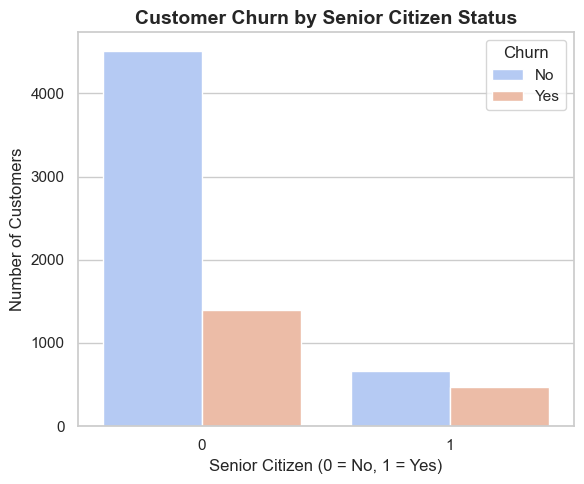

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn",
    palette="coolwarm"
)

plt.title("Customer Churn by Senior Citizen Status", fontsize=14, fontweight="bold")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

Although there are fewer senior citizens overall, a relatively larger proportion of them appear to churn.

### Business Insight

Senior citizens may require additional support, customized plans, or improved customer service to enhance retention.

## Customer Tenure Distribution

Customer tenure represents the number of months a customer has stayed with the company.

Analyzing its distribution helps us understand customer retention.

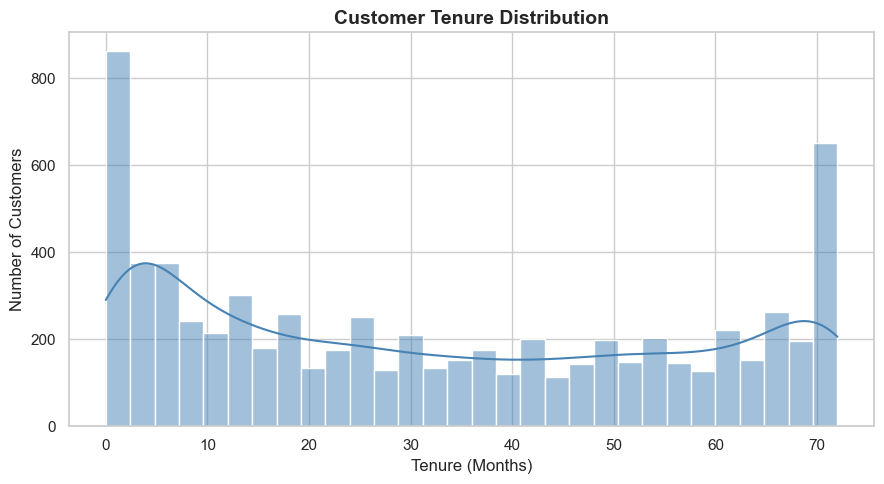

In [14]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Customer Tenure Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Tenure (Months)")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

### Observation

Many customers have either very short tenure or very long tenure.

### Business Insight

Customer retention strategies should focus on retaining new customers during the first few months.

## Monthly Charges by Churn

Analyze how monthly charges differ between churned and retained customers.

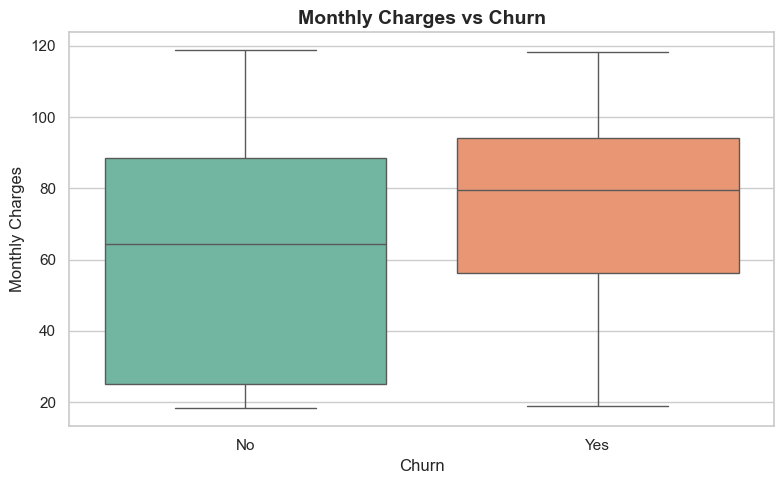

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Monthly Charges vs Churn", fontsize=14, fontweight="bold")

plt.xlabel("Churn")

plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.show()

### Observation

Customers who churn tend to have higher monthly charges.

### Business Insight

Higher pricing may contribute to customer dissatisfaction and increase the likelihood of churn.

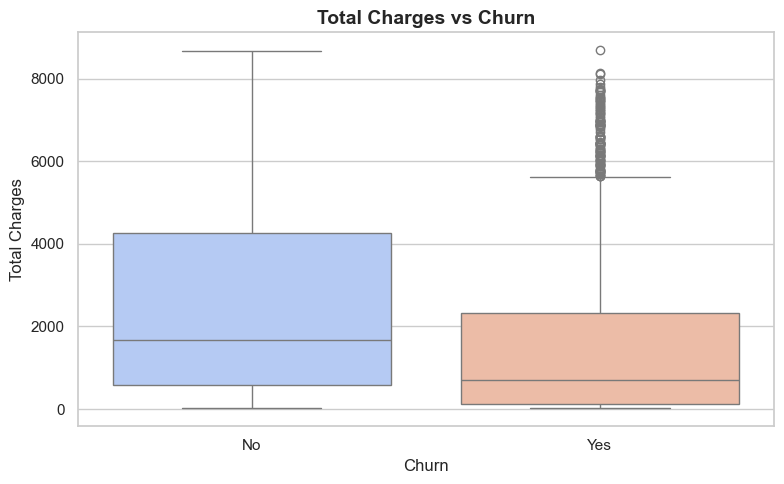

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges",
    hue="Churn",
    palette="coolwarm",
    legend=False
)

plt.title("Total Charges vs Churn", fontsize=14, fontweight="bold")

plt.xlabel("Churn")

plt.ylabel("Total Charges")

plt.tight_layout()

plt.show()

### Observation

Customers who remain with the company generally have higher total charges.

### Business Insight

Higher total charges are associated with longer customer tenure rather than increased monthly cost.

In [17]:
eda_df = df.copy()

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in eda_df.columns:
    if eda_df[column].dtype == "object":
        eda_df[column] = encoder.fit_transform(eda_df[column].astype(str))

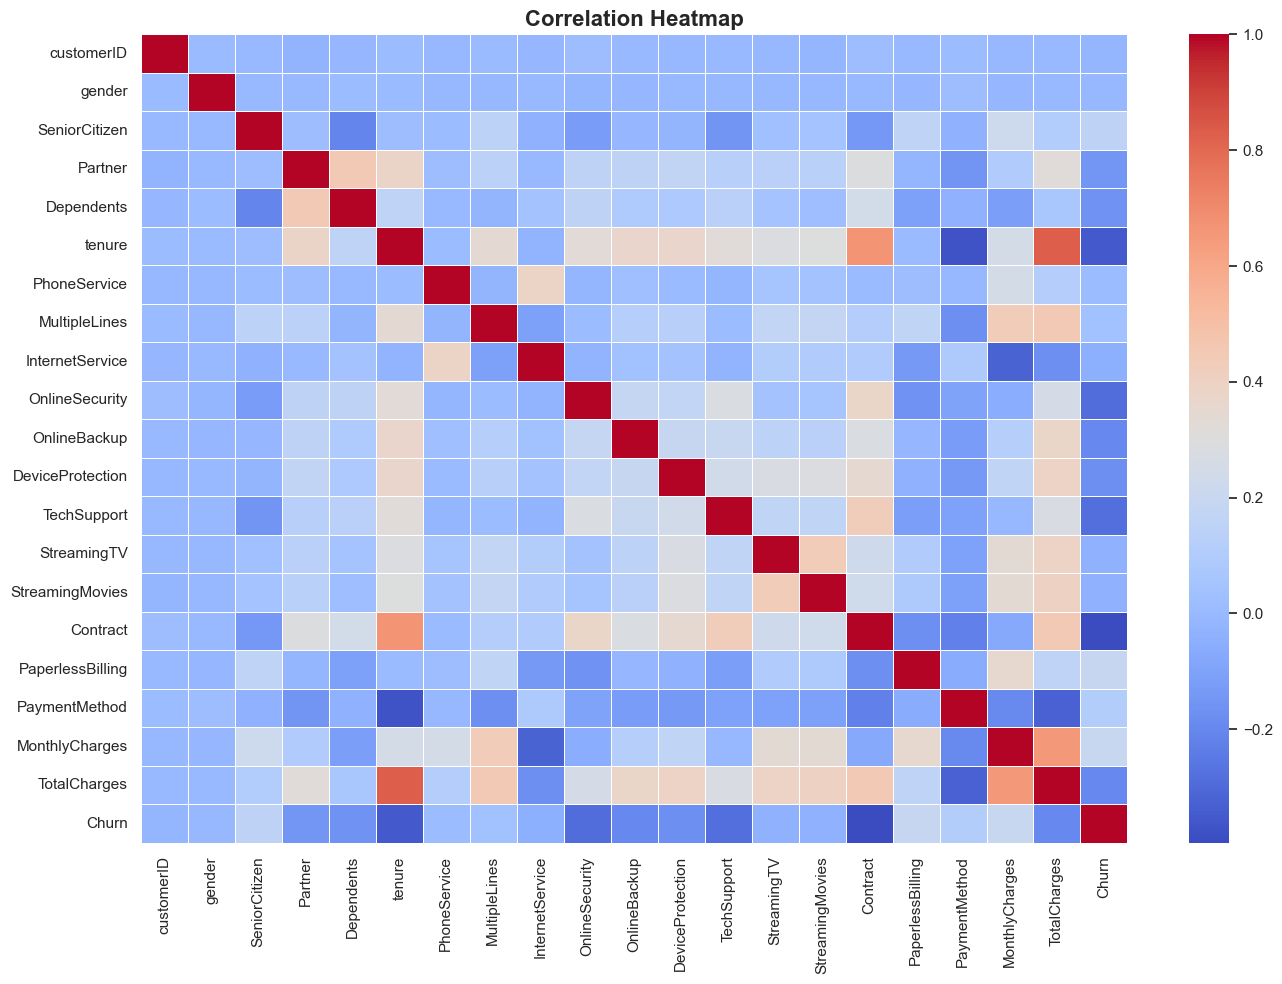

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(
    eda_df.corr(),
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Key Business Insights

## Customer Retention

- Customers with Month-to-month contracts show the highest churn.
- Long-term contracts improve customer retention.

## Pricing

- Customers paying higher monthly charges are more likely to churn.

## Internet Service

- Fiber optic customers exhibit higher churn compared to DSL customers.

## Payment Methods

- Customers using Electronic Check have the highest churn.

## Customer Demographics

- Gender has little influence on churn.
- Senior citizens have a relatively higher churn proportion.

## Tenure

- Customers with shorter tenure are more likely to leave.
- Long-term customers are more loyal.

# Conclusion

The exploratory data analysis identified several factors strongly associated with customer churn.

Contract type, tenure, monthly charges, internet service, and payment method emerged as the most influential variables.

Gender showed minimal influence on churn, whereas senior citizens displayed a relatively higher churn proportion.

These findings provide valuable direction for feature engineering and machine learning model development in the next phase of the project.